In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/data.csv")

In [4]:
# Handle DATE
df['DATE'] = pd.to_datetime(df['DATE'])
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['hour'] = df['DATE'].dt.hour
df = df.drop('DATE', axis=1)

# Drop correlated / useless features
df = df.drop(['WETBULBTEMPF','DewPointTempF','StationPressure'], axis=1)
df = df.drop('Precip', axis=1)

In [5]:
X = df.drop('VISIBILITY', axis=1)
y = df['VISIBILITY']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    
    results.append((name, score))
    print(f"{name}: {score}")

Linear Regression: 0.2597658237638516
Ridge: 0.2597657769616669
Lasso: 0.008937836461471615
Decision Tree: 0.49064754526322685
Random Forest: 0.7342939485513613


In [9]:
results_df = pd.DataFrame(results, columns=["Model", "R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
4,Random Forest,0.734294
3,Decision Tree,0.490648
0,Linear Regression,0.259766
1,Ridge,0.259766
2,Lasso,0.008938


Report:

1. Random Forest performed best
Captures non-linear relationships
Robust to noise and feature interactions
Suitable for tabular weather data

2. Decision Tree performed moderately
Handles non-linearity
But suffers from overfitting

3. Linear Models performed poorly
Assumes linear relationships
Weather data is complex & non-linear
Hence low R² (~0.25)

4. Lasso performed worst
Strong regularization → removed useful features
Underfitting occurred


Conclusion:

Random Forest is selected as the final model due to its superior performance (R² ≈ 0.73) and ability to model complex relationships in the dataset.

Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [11]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Tuned R2:", r2_score(y_test, y_pred))

Tuned R2: 0.7352727335528906


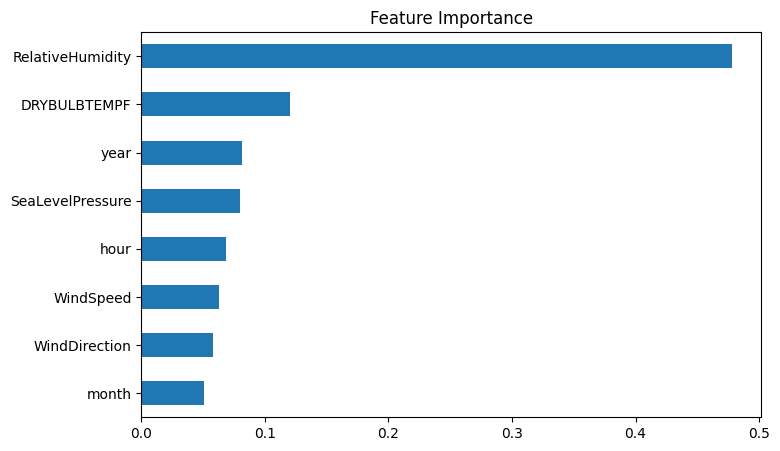

In [13]:
#Feature Importance

import matplotlib.pyplot as plt
import pandas as pd

importances = best_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)

feat_imp.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()

Report: 

Feature importance analysis shows that variables such as temperature, humidity, and pressure significantly influence visibility prediction.

In [14]:
import joblib

joblib.dump(best_model, "model.pkl")

['model.pkl']